Invalid Data Points:
Empty DataFrame
Columns: [Date, Ppt, Tair, RH, Wind speed, Wind direction, Srad]
Index: []

Missing Data:
Tair              1531
RH                1531
Wind speed        1531
Wind direction    1531
Srad              1627
dtype: int64


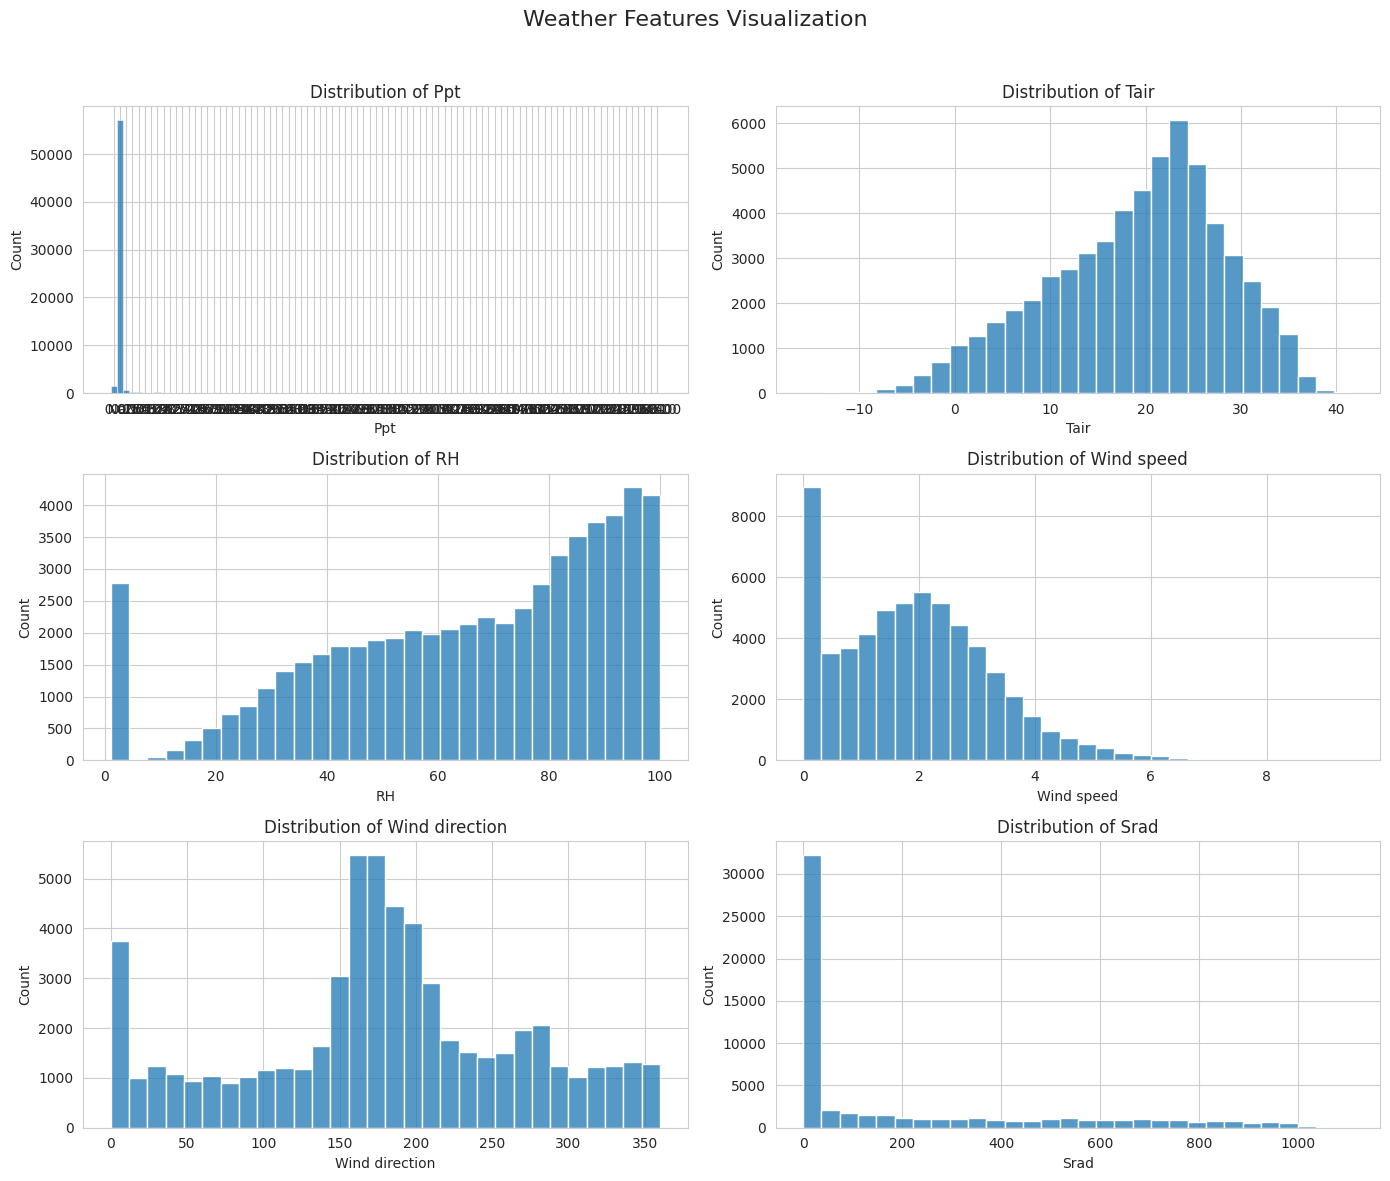

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset without limiting rows
df = pd.read_csv('MET_6.dat')

# Clean column names
df.columns = df.columns.str.strip()

# Convert relevant columns to numeric, coercing errors to NaN
df[['Tair', 'RH', 'Wind speed', 'Wind direction', 'Srad']] = df[['Tair', 'RH', 'Wind speed', 'Wind direction', 'Srad']].apply(pd.to_numeric, errors='coerce')

# Set the style for the plots
sns.set_style("whitegrid")

# Optimized function to validate data based on criteria
def validate_data(df):
    mask = (
        ((df['Tair'] < -50) | (df['Tair'] > 50)) |
        ((df['RH'] < 0) | (df['RH'] > 100)) |
        ((df['Wind speed'] < 0) | (df['Wind speed'] > 25)) |
        ((df['Wind direction'] < 0) | (df['Wind direction'] > 360)) |
        (df['Srad'] < 0)
    )
    return df[mask]

# Run validation on the dataset
invalid_data = validate_data(df)
print("Invalid Data Points:")
print(invalid_data)

# Display missing data summary
missing_data = df.isnull().sum()
print("\nMissing Data:")
print(missing_data[missing_data > 0])

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Weather Features Visualization', fontsize=16)

# Define features and axes mapping
features = ['Ppt', 'Tair', 'RH', 'Wind speed', 'Wind direction', 'Srad']
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    if feature in df.columns:
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[i])  # KDE disabled for speed
        axes[i].set_title(f'Distribution of {feature}')
    else:
        axes[i].text(0.5, 0.5, f'{feature} not found', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()